<h3>LIBRERIAS</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

<h3>CARGAR</h3>

In [2]:
ruta = Path(r"../1. Datasets/2. Dataset Limpio")

df = pd.read_parquet(ruta/"dopamine_trigger_metrics.parquet")

In [3]:
df.head()

,id_usuario,anio,pais,grupo_edad,genero,plataforma,tasa_interaccion,horas_consumo_video_corto,puntaje_activacion_dopamina,dependencia_gratificacion_inmediata,consumo_video_categoria,tasa_interaccion_categoria
0,12136,2054,Spain,Teen,Male,Snapchat,78.70,3.70,62.71,36.53,Moderado,Alta
1,3774,2039,Canada,Senior,Female,TikTok,6.40,4.09,3.67,32.79,Moderado,Baja
2,21305,2030,USA,Children,Male,Discord,82.20,2.88,18.75,76.64,Moderado,Alta
3,19767,2057,Japan,Young Adult,Male,YouTube,62.29,2.15,4.62,5.78,Moderado,Media
4,19584,2049,Turkey,Children,Other,Twitch,80.69,0.14,63.87,87.84,Bajo,Alta


In [4]:
df.columns

Index(['id_usuario', 'anio', 'pais', 'grupo_edad', 'genero', 'plataforma',
       'tasa_interaccion', 'horas_consumo_video_corto',
       'puntaje_activacion_dopamina', 'dependencia_gratificacion_inmediata',
       'consumo_video_categoria', 'tasa_interaccion_categoria'],
      dtype='object')

In [3]:
df = df[df['anio'].between(2010, 2025)]

df

,id_usuario,anio,pais,grupo_edad,genero,plataforma,tasa_interaccion,horas_consumo_video_corto,puntaje_activacion_dopamina,dependencia_gratificacion_inmediata
6,9137,2016,Indonesia,Children,Female,LinkedIn,69.47,7.14,21.17,90.85
7,11354,2025,USA,Senior,Female,YouTube,3.64,5.73,89.97,52.45
12,1421,2022,France,Teen,Male,TikTok,73.00,2.28,39.26,32.11
13,17949,2019,Turkey,Adult,Male,YouTube,59.39,6.11,47.84,29.78
14,18907,2023,Canada,Senior,Other,LinkedIn,14.47,6.58,95.58,11.83
...,...,...,...,...,...,...,...,...,...,...
49971,17739,2015,China,Children,Male,LinkedIn,18.22,4.17,62.03,66.66
49981,3695,2012,Australia,Young Adult,Male,LinkedIn,46.24,5.31,36.07,89.78
49994,4288,2021,Japan,Senior,Other,YouTube,83.28,8.17,32.22,49.37
49998,5458,2021,UAE,Adult,Other,Twitch,33.68,9.26,19.06,41.75


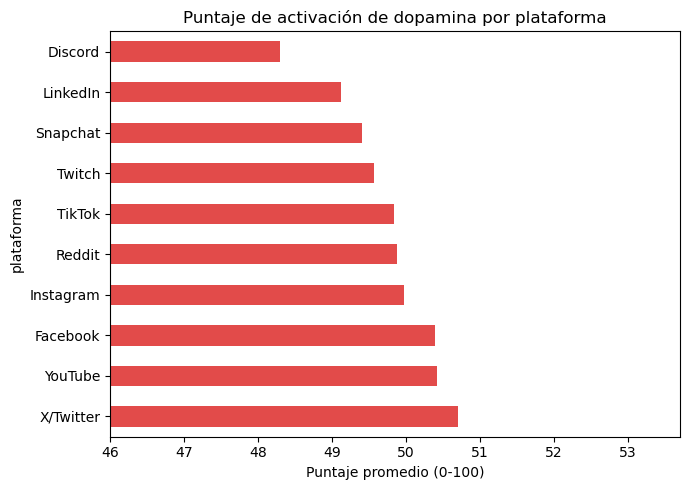

In [ ]:
# 1. ACTIVACIÓN DE DOPAMINA POR PLATAFORMA 
plat_dopamina = df.groupby('plataforma')['puntaje_activacion_dopamina'].mean().sort_values(ascending=False)
plat_dopamina.plot(kind='barh', figsize=(7, 5), color='#E24B4A')
plt.title('Puntaje de activación de dopamina por plataforma')
plt.xlabel('Puntaje promedio (0-100)')
plt.xlim(46, plat_dopamina.max() + 3)
plt.tight_layout()
plt.show()

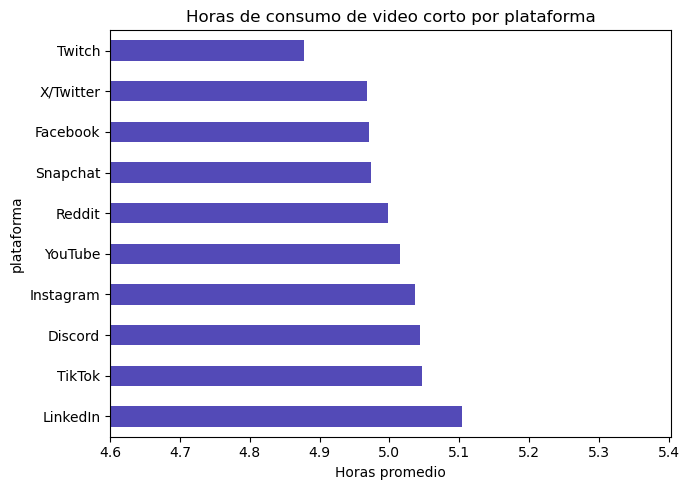

In [ ]:
#  2. HORAS DE VIDEO CORTO POR PLATAFORMA 
plat_video = df.groupby('plataforma')['horas_consumo_video_corto'].mean().sort_values(ascending=False)
plat_video.plot(kind='barh', figsize=(7, 5), color='#534AB7')
plt.title('Horas de consumo de video corto por plataforma')
plt.xlabel('Horas promedio')
plt.xlim(4.6, plat_video.max() + 0.3)
plt.tight_layout()
plt.show()

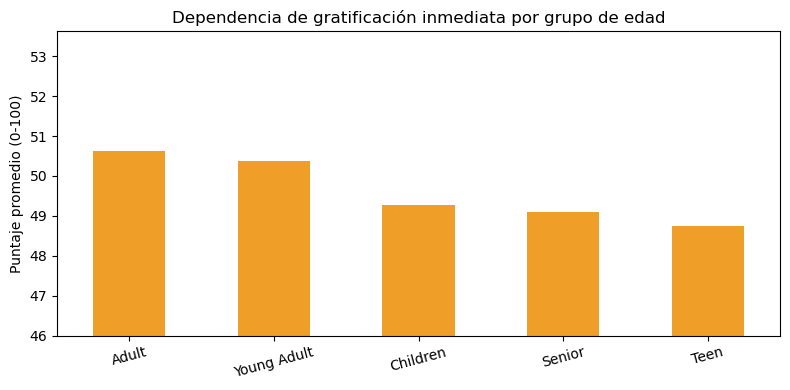

In [ ]:
# 3. DEPENDENCIA DE GRATIFICACIÓN INMEDIATA POR GRUPO DE EDAD 
edad_dep = df.groupby('grupo_edad')['dependencia_gratificacion_inmediata'].mean().sort_values(ascending=False)
edad_dep.plot(kind='bar', figsize=(8, 4), color='#EF9F27')
plt.title('Dependencia de gratificación inmediata por grupo de edad')
plt.ylabel('Puntaje promedio (0-100)')
plt.ylim(46, edad_dep.max() + 3)
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

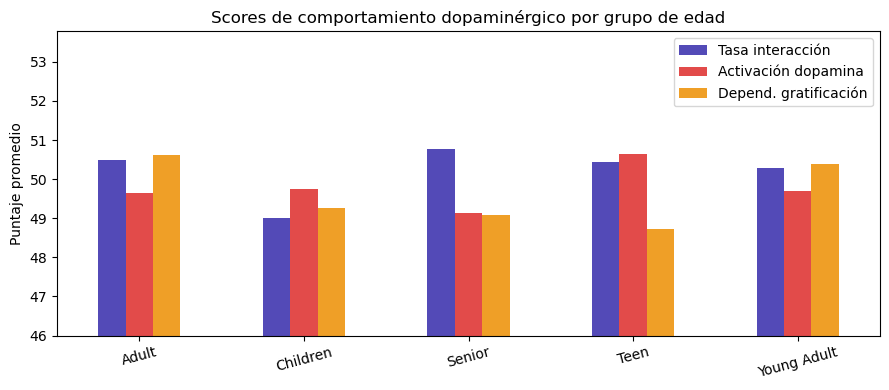

In [ ]:
# 4. SCORES COMPARADOS POR GRUPO DE EDAD 
cols_scores = ['tasa_interaccion', 'puntaje_activacion_dopamina', 'dependencia_gratificacion_inmediata']
edad_scores = df.groupby('grupo_edad')[cols_scores].mean()
edad_scores.plot(kind='bar', figsize=(9, 4), color=['#534AB7', '#E24B4A', '#EF9F27'])
plt.title('Scores de comportamiento dopaminérgico por grupo de edad')
plt.ylabel('Puntaje promedio')
plt.ylim(46, edad_scores.values.max() + 3)
plt.xlabel('')
plt.xticks(rotation=15)
plt.legend(['Tasa interacción', 'Activación dopamina', 'Depend. gratificación'])
plt.tight_layout()
plt.show()

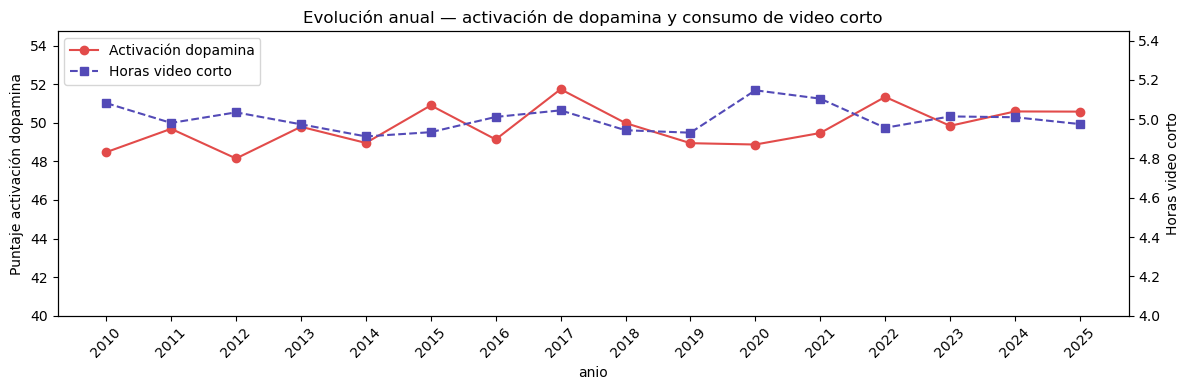

In [13]:
# --- 5. EVOLUCIÓN ANUAL --- 
anio_scores = df.groupby('anio')[['puntaje_activacion_dopamina', 'horas_consumo_video_corto']].mean()
fig, ax = plt.subplots(figsize=(12, 4))
anio_scores['puntaje_activacion_dopamina'].plot(ax=ax, marker='o', color='#E24B4A', label='Activación dopamina')
ax2 = ax.twinx()
anio_scores['horas_consumo_video_corto'].plot(ax=ax2, marker='s', color='#534AB7', label='Horas video corto', linestyle='--')
ax.set_title('Evolución anual — activación de dopamina y consumo de video corto')
ax.set_ylabel('Puntaje activación dopamina')
ax2.set_ylabel('Horas video corto')
ax.set_ylim(40, anio_scores['puntaje_activacion_dopamina'].max() + 3)
ax2.set_ylim(4, anio_scores['horas_consumo_video_corto'].max() + 0.3)
ax.set_xticks(anio_scores.index)
ax.tick_params(axis='x', rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

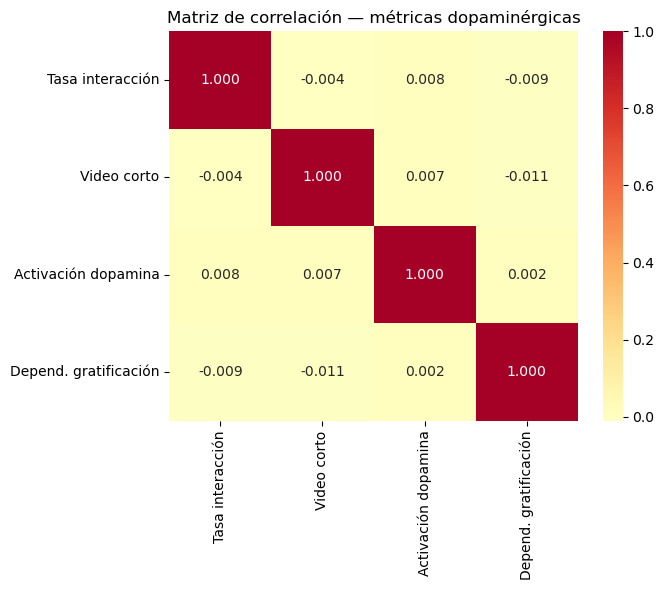

In [14]:
# 6. MATRIZ DE CORRELACIÓN 
cols_num = ['tasa_interaccion', 'horas_consumo_video_corto',
            'puntaje_activacion_dopamina', 'dependencia_gratificacion_inmediata']
corr = df[cols_num].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            xticklabels=['Tasa interacción', 'Video corto', 'Activación dopamina', 'Depend. gratificación'],
            yticklabels=['Tasa interacción', 'Video corto', 'Activación dopamina', 'Depend. gratificación'],
            ax=ax)
ax.set_title('Matriz de correlación — métricas dopaminérgicas')
plt.tight_layout()
plt.show()